<a href="https://colab.research.google.com/github/np03cs4a240010-collab/Ai/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regression Task

In [29]:
import pandas as pd

path = "/content/drive/MyDrive/Ai/health_lifestyle_dataset.csv"
df = pd.read_csv(path)
df.head()

,id,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,1,56,Male,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,2,69,Female,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,3,46,Male,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,4,32,Female,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,5,60,Female,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


Shape, columns, data types

In [30]:
df.shape

(100000, 16)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 100000 non-null  int64  
 1   age                100000 non-null  int64  
 2   gender             100000 non-null  object 
 3   bmi                100000 non-null  float64
 4   daily_steps        100000 non-null  int64  
 5   sleep_hours        100000 non-null  float64
 6   water_intake_l     100000 non-null  float64
 7   calories_consumed  100000 non-null  int64  
 8   smoker             100000 non-null  int64  
 9   alcohol            100000 non-null  int64  
 10  resting_hr         100000 non-null  int64  
 11  systolic_bp        100000 non-null  int64  
 12  diastolic_bp       100000 non-null  int64  
 13  cholesterol        100000 non-null  int64  
 14  family_history     100000 non-null  int64  
 15  disease_risk       100000 non-null  int64  
dtypes: 

Missing values

In [32]:
df.isna().sum()

,0
id,0
age,0
gender,0
bmi,0
daily_steps,0
sleep_hours,0
water_intake_l,0
calories_consumed,0
smoker,0
alcohol,0


Duplicate rows

In [33]:
df.duplicated().sum()

np.int64(0)

Target variable distribution

In [34]:
df['disease_risk'].describe()

,disease_risk
count,100000.000000
mean,0.248210
std,0.431976
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


Data Cleaning & Preprocessing
Drop ID column

In [35]:
df = df.drop(columns=['id'])

Encode categorical column (gender)

In [36]:
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

In [37]:
df.head()

,age,gender,bmi,daily_steps,sleep_hours,water_intake_l,calories_consumed,smoker,alcohol,resting_hr,systolic_bp,diastolic_bp,cholesterol,family_history,disease_risk
0,56,0,20.5,4198,3.9,3.4,1602,0,0,97,161,111,240,0,0
1,69,1,33.3,14359,9.0,4.7,2346,0,1,68,116,65,207,0,0
2,46,0,31.6,1817,6.6,4.2,1643,0,1,90,123,99,296,0,0
3,32,1,38.2,15772,3.6,2.0,2460,0,0,71,165,95,175,0,0
4,60,1,33.6,6037,3.8,4.0,3756,0,1,98,139,61,294,0,0


In [38]:
import matplotlib.pyplot as plt

Target distribution

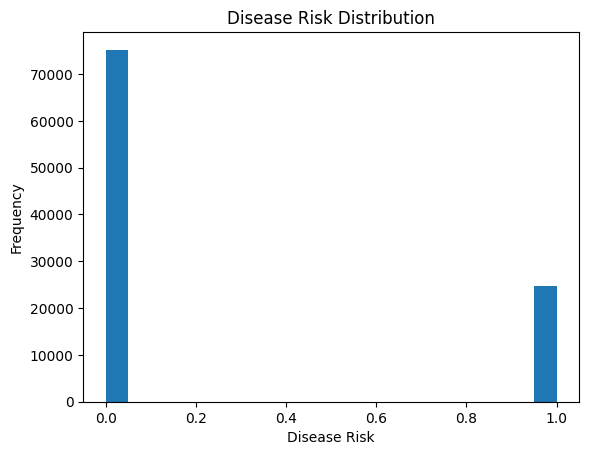

In [39]:
plt.hist(df['disease_risk'], bins=20)
plt.title("Disease Risk Distribution")
plt.xlabel("Disease Risk")
plt.ylabel("Frequency")
plt.show()

Correlation with target

In [40]:
corr = df.corr()['disease_risk'].sort_values(ascending=False)
corr

,disease_risk
disease_risk,1.000000
resting_hr,0.005437
bmi,0.003586
family_history,0.003225
calories_consumed,0.002737
sleep_hours,0.002582
gender,0.001957
age,0.001671
smoker,0.001125
systolic_bp,0.001086


Top correlated features

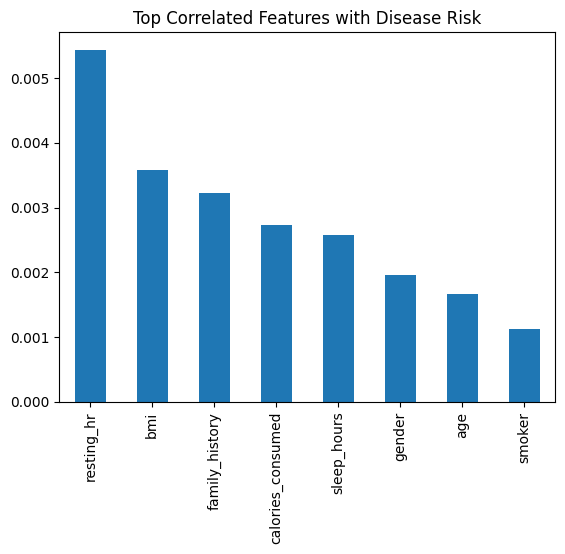

In [41]:
corr.drop('disease_risk').head(8).plot(kind='bar')
plt.title("Top Correlated Features with Disease Risk")
plt.show()

Train/Test Split

In [42]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['disease_risk'])
y = df['disease_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Neural Network Regression Model
Build MLP Regressor

In [44]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)

Evaluate MLP

In [45]:
import numpy as np
mlp_train_pred = mlp.predict(X_train_scaled)
mlp_test_pred = mlp.predict(X_test_scaled)

print("MLP Train RMSE:", np.sqrt(mean_squared_error(y_train, mlp_train_pred)))
print("MLP Test RMSE:", np.sqrt(mean_squared_error(y_test, mlp_test_pred)))
print("MLP Test R2:", r2_score(y_test, mlp_test_pred))

MLP Train RMSE: 0.4233235830309794
MLP Test RMSE: 0.4396453862554435
MLP Test R2: -0.03669958434360465


Linear Regression

In [46]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression RMSE: 0.43189461535884904
Linear Regression R2: -0.0004686019978705769


Random Forest Regressor

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest RMSE: 0.43659895928643716
Random Forest R2: -0.022382193378776005


Hyperparameter Tuning
GridSearch – Linear Regression

In [48]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10]
}

grid_ridge = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring='r2'
)

grid_ridge.fit(X_train_scaled, y_train)

grid_ridge.best_params_, grid_ridge.best_score_

({'alpha': 10}, np.float64(-0.00018486478958676945))

SelectKBest (Filter Method)

In [49]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler

# Re-apply scaling as X_train_scaled might not be defined
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

selector = SelectKBest(score_func=f_regression, k=8)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel = selector.transform(X_test_scaled)

Final Ridge Regression

In [50]:
final_ridge = Ridge(alpha=grid_ridge.best_params_['alpha'])
final_ridge.fit(X_train_sel, y_train)

ridge_final_pred = final_ridge.predict(X_test_sel)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_final_pred))
ridge_r2 = r2_score(y_test, ridge_final_pred)